# Atmospheric Transmission

Plot near- and mid-IR atmospheric transmission spectra.

## Sources

### General Source:

  www.gemini.edu/sciops/telescopes-and-sites/observing-condition-constraints

At near-IR (0.9-6um), they provide calculations for airmasses 1.0, 1.5, and 2.0 for water vapor columns of 1.0, 1.6, and 3.0mm of precipitable water, respectively (9 data tables).  Data are calculated by ATRAN.

For mid-IR (6-28um), the data are provided for airmass 1.5 for water columns of 1.0, 1.6, 3.0, and 5.0mm of precipitable water.

### Source Acknowledgement:

https://ui.adsabs.harvard.edu/abs/1992nstc.rept.....L

```
  Lord, S.D. 1992, NASA Technical Memorandum 103957
```
And for these files, also cite the Gemini Observatory.

## 6-28um midIR sky transmission
```
 mid-IR sky transmission 6 - 28 um
 1.0mm H2O, sec z = 1.5
  
 Modification of original spectrum from ATRANS via Tom Geballe
 14Dec99 - converted to units of nm from um by Phil Puxley
```

URL: www.gemini.edu/sciops/ObsProcess/obsConstraints/atm-models/midIR_trans_10_15.dat

## 0.9-10um sky transmission

```
 1.0mm H20, airmass=1.0
```

URL: www.gemini.edu/sciops/ObsProcess/obsConstraints/atm-models/trans_10_10.dat


In [1]:
%matplotlib inline

import os, sys, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  


In [2]:
# graphic aspect ratio = width/height

#aspect = 4.0/3.0  # letter paper
#aspect = 16.0/9.0 # wide-screen
aspect = 2.5 # spectral

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Data

### Near-IR

File: `nearIR_trans_10_10.txt`, PWV 1mm, airmass=1.0

2-columns:
 * col1: wavelength in microns
 * col2: transmission (0..1)

### Mid-IR

File: `midIR_trans_10_15.txt`, PWF 1mm, airmass 1.5

2-columns:
 * col1: wavelength in microns
 * col2: transmission (0..1)

In [3]:
# ATRAN data from Gemini

dataFile = "nearIR_trans_10_10.txt"
data = pd.read_csv(dataFile,sep=r'\s+',comment='#',header=None)

nirLam = np.array(data[0])
nirTran = np.array(data[1])

dataFile = "midIR_trans_10_15.txt"
data = pd.read_csv(dataFile,sep=r'\s+',comment='#',header=None)

mirLam = np.array(data[0])
mirTran = np.array(data[1])

# axis limits

minLam = 0.9 # microns
maxLam = 28.0 

minTran = -0.05
maxTran = 1.05


## Near- to Mid-IR transmission

Plot atmospheric transmission from 0.9 to 28 microns, labeling the main water, carbon dioxide, and ozone bands

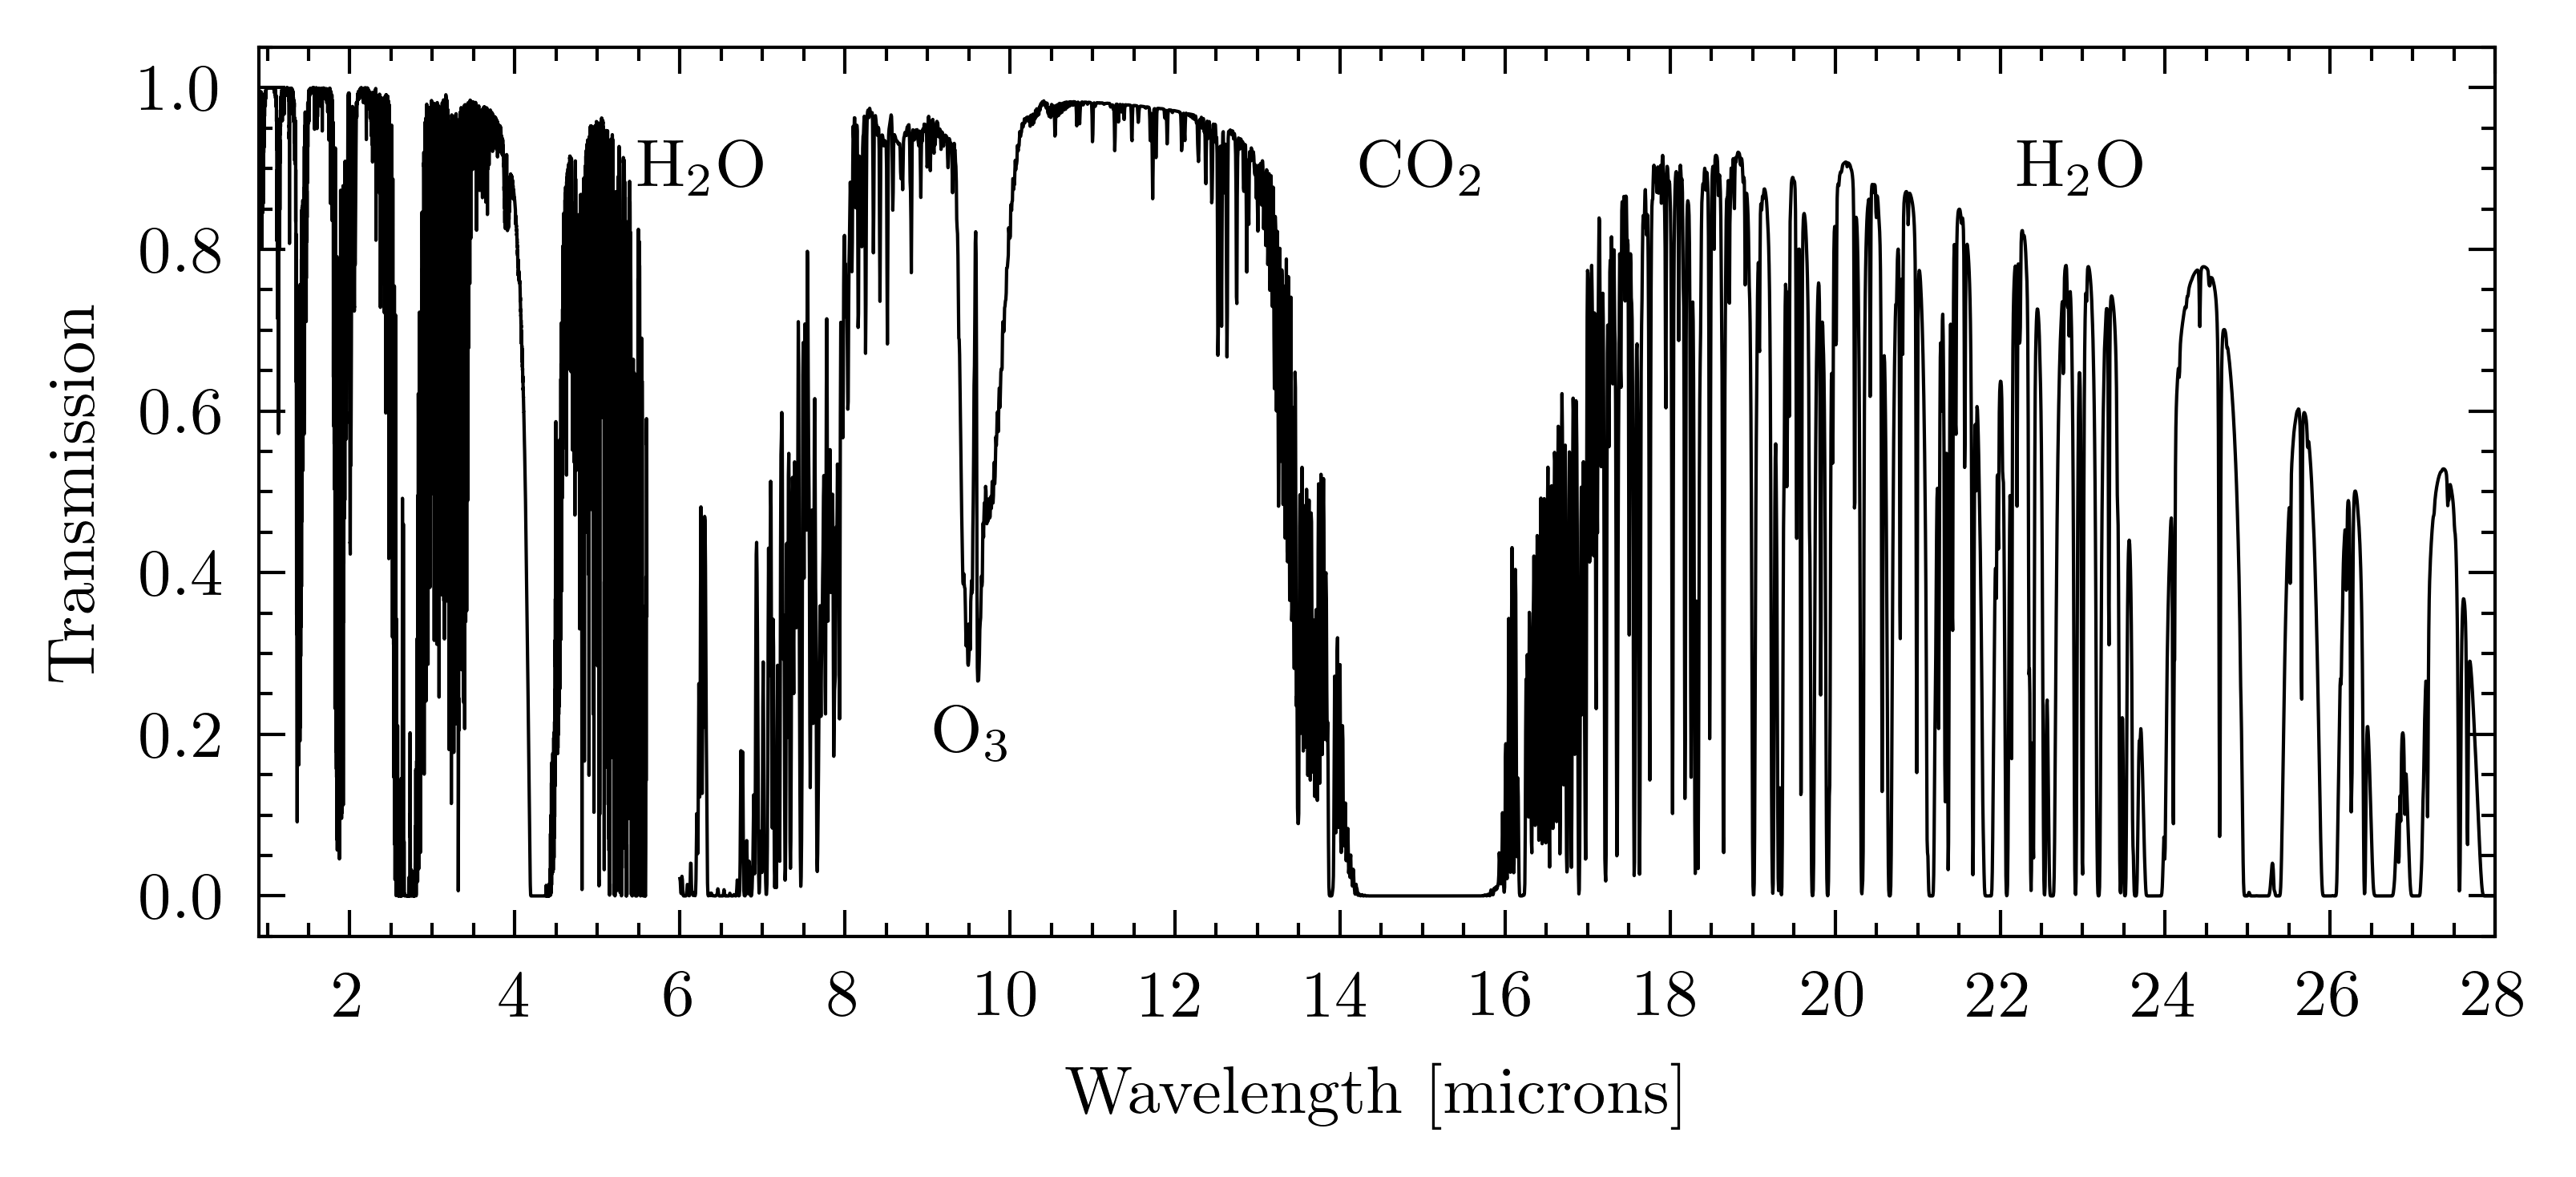

In [4]:
plotFile = "atmos_mirtrans.png"
annotate = True

# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(minLam,maxLam)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.set_xlabel(r'Wavelength [microns]',fontsize=axisFontSize)

ax.set_ylim(minTran,maxTran)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_ylabel(r'Transmission',fontsize=axisFontSize)

ax.plot(nirLam,nirTran,'-',color='black',lw=0.5)
ax.plot(mirLam,mirTran,'-',color='black',lw=0.5)

# annotations of major bands

if annotate:
    ax.text(6.28,0.9,r"H$_2$O",ha='center',va='center',fontsize=axisFontSize)
    ax.text(9.55,0.2,r"O$_3$",ha='center',va='center',fontsize=axisFontSize)
    ax.text(15.0,0.9,r"CO$_2$",ha='center',va='center',fontsize=axisFontSize)
    ax.text(23,0.9,r"H$_2$O",ha='center',va='center',fontsize=axisFontSize)

# Make the plot

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

## Near-IR transmission

Plot atmospheric transmission from 0.9 to 5.6 microns, labeling bands of water, oxygen, carbon dioxide, methane
and ozone

Zoom in on the short-wavelength side of the plot above.

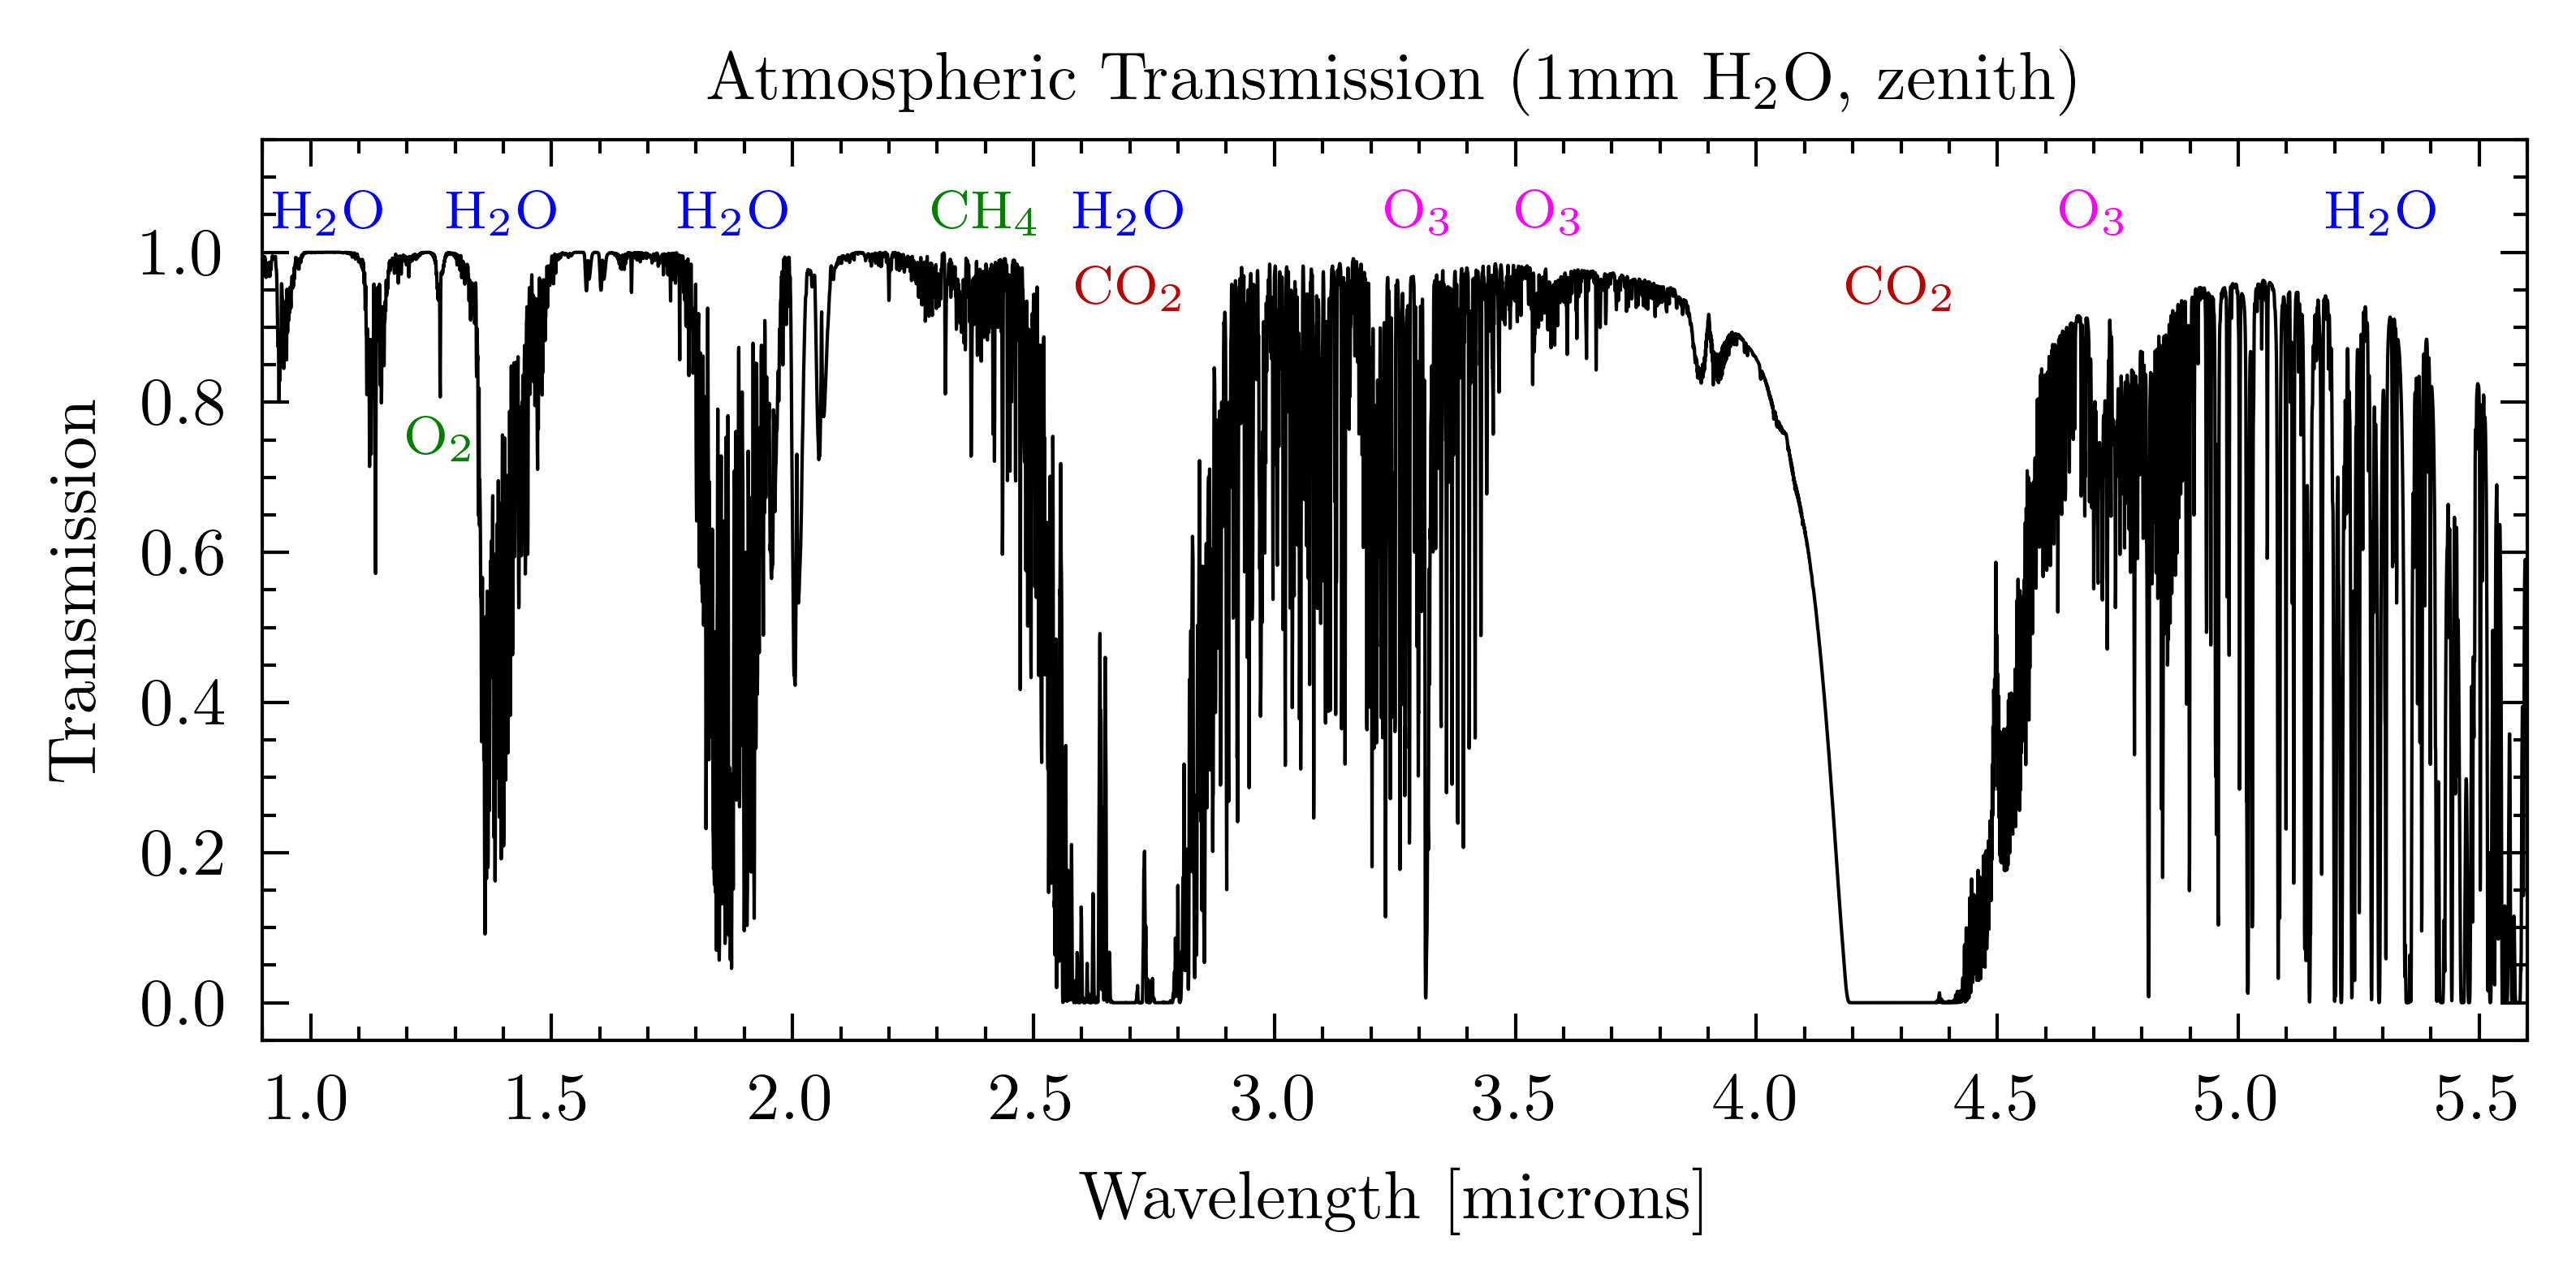

In [6]:
plotFile = "atmos_nirtrans.png"
minLam = 0.9
maxLam = 5.6
maxTran = 1.15 # more room for labels
annotate = True

# make the plot

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(minLam,maxLam)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_xlabel(r'Wavelength [microns]',fontsize=axisFontSize)

ax.set_ylim(minTran,maxTran)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_ylabel(r'Transmission',fontsize=axisFontSize)

ax.plot(nirLam,nirTran,'-',color='black',lw=0.5)
ax.plot(mirLam,mirTran,'-',color='black',lw=0.5)

# annotations of major bands

if annotate:
    h2owav = [1.04,1.4,1.88,2.7,5.3]
    o3wav = [3.3,3.57,4.7]
    co2wav = [2.7,4.3]
    o2wav = 1.269
    ch4wav = 2.4

    for lam in h2owav:
        ax.text(lam,1.05,r"H$_2$O",ha='center',va='center',color='blue',fontsize=labelFontSize)

    for lam in o3wav:
        ax.text(lam,1.05,r"O$_3$",ha='center',va='center',color='magenta',fontsize=labelFontSize)

    for lam in co2wav:
        ax.text(lam,0.95,r"CO$_2$",ha='center',va='center',color='#bb0000',fontsize=labelFontSize)
    
    ax.text(ch4wav,1.05,r"CH$_4$",ha='center',va='center',color='green',fontsize=labelFontSize)
    ax.text(o2wav,0.75,r"O$_2$",ha='center',va='center',color='green',fontsize=labelFontSize)

# Make the plot

ax.set_title(r"Atmospheric Transmission (1mm H$_2$O, zenith)",fontsize=axisFontSize)

plt.plot()
plt.savefig(plotFile,bbox_inches='tight',facecolor='white')